## Business Problem

This dataset contains information about drug classification based on patient general information and its diagnosis.Machine learning model is needed in
##### order to predict the outcome of the drugs type that might be suitable for the patient.

The following is the structure of the data set.

| Variable Name | Description | Sample Data |
|--------------|-------------|---------------|
|Age | Patient Age | 23; 47; ... |
|Sex | Gender of patient (male or female) | F; M; ... |
|BP | Levels of blood pressure (high, normal, or low) | HIGH; NORMAL; LOW; ... |
|Cholesterol | Levels of cholesterol (high or normal) | 1.4; 1.3; ... |
|Na_to_K | Sodium to potassium ratio in blood | 25.355; 13.093; ... |
| Drug | Type of drug | DrugY; drugC; ... |

### Importing Library

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [58]:
df_drug = pd.read_csv("D:\Data Science\Assignment\drug200.csv")

In [59]:
df_drug.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [60]:
df_drug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


### Initial Data Exploration

#### Categorical Variables

In [61]:
df_drug.Drug.value_counts()

Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [62]:
df_drug.Sex.value_counts()

Sex
M    104
F     96
Name: count, dtype: int64

In [63]:
df_drug.BP.value_counts()

BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64

In [64]:
df_drug.Cholesterol.value_counts()

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64

## Numerical Variables

In [65]:
df_drug.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [66]:
skewAge = df_drug.Age.skew(axis = 0, skipna = True)
print('Age Skewness: ',skewAge)

Age Skewness:  0.03030835703000607


In [67]:
skewNatok = df_drug.Na_to_K.skew(axis =0,skipna =True)
print('Na_to_K skewness: ',skewNatok)

Na_to_K skewness:  1.039341186028881


C:\Users\nived\AppData\Local\Temp\ipykernel_11332\2801843725.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_drug['Age']);


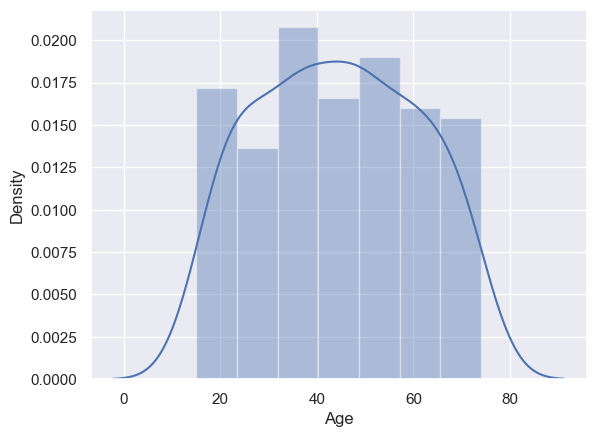

In [68]:
sns.distplot(df_drug['Age']);

C:\Users\nived\AppData\Local\Temp\ipykernel_11332\2008204568.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_drug['Na_to_K']);


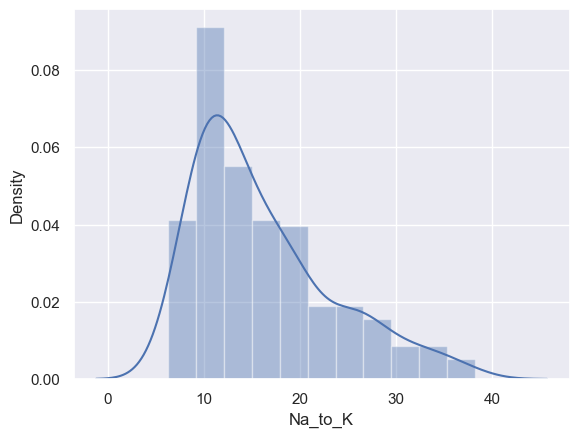

In [69]:
sns.distplot(df_drug['Na_to_K']);

 - The distribution of 'Age' column is symetric, since the skewness value between -0.5 and 0.5
 - The distribution of 'Na_to_K' column is moderately skewed, since the skewness value is between 0.5 and 1. It can also be seen from the histogram for
'Na_to_K' column

## EDA

### Drug Type Distribution

C:\Users\nived\AppData\Local\Temp\ipykernel_11332\948472731.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y = 'Drug',data =df_drug,palette='flare',hue=None,legend='Drug')


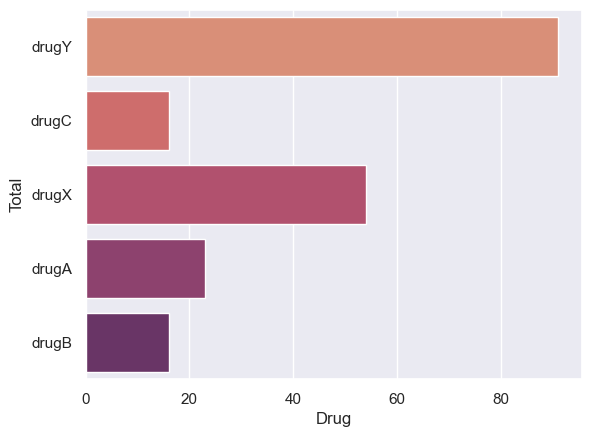

In [70]:
sns.set_theme(style='darkgrid')
sns.countplot(y = 'Drug',data =df_drug,palette='flare',hue=None,legend='Drug')
plt.xlabel('Drug')
plt.ylabel('Total')
plt.show()

## Gender Distribution


C:\Users\nived\AppData\Local\Temp\ipykernel_11332\4087156412.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Sex',data=df_drug,palette='rocket')


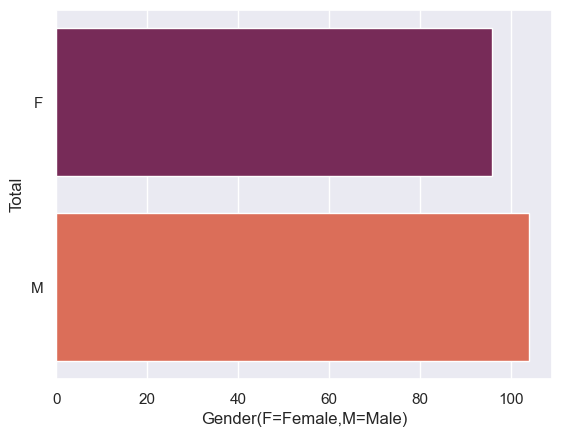

In [71]:
sns.set_theme(style='darkgrid')
sns.countplot(y='Sex',data=df_drug,palette='rocket')
plt.xlabel('Gender(F=Female,M=Male)')
plt.ylabel("Total")
plt.show()

## Blood Pressure Distribution

C:\Users\nived\AppData\Local\Temp\ipykernel_11332\3845294725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='BP',data=df_drug,palette='crest')


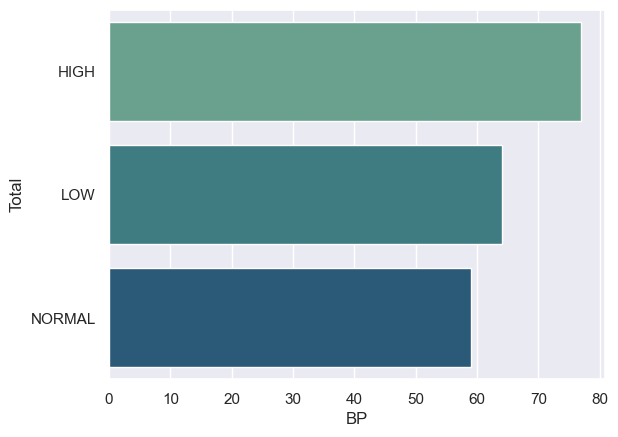

In [72]:
sns.set_theme(style='darkgrid')
sns.countplot(y='BP',data=df_drug,palette='crest')
plt.xlabel('BP')
plt.ylabel('Total')
plt.show()

## Cholesterol Distribution

C:\Users\nived\AppData\Local\Temp\ipykernel_11332\2308587784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y ='Cholesterol',data=df_drug,palette='magma')


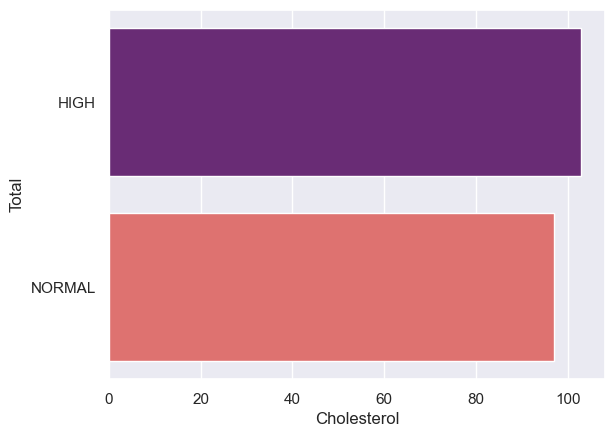

In [73]:
sns.set_theme(style='darkgrid')
sns.countplot(y ='Cholesterol',data=df_drug,palette='magma')
plt.xlabel('Cholesterol')
plt.ylabel('Total')
plt.show()

## Gender Distribution based on Drug Type

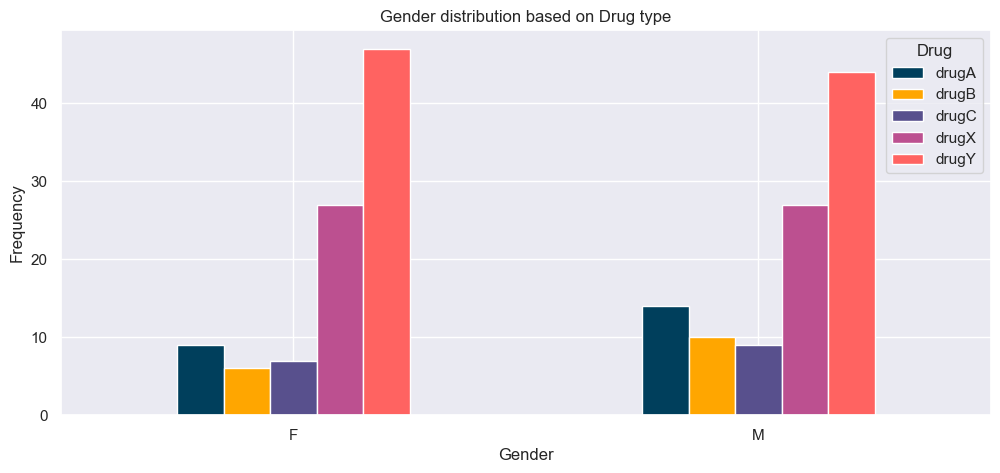

In [74]:
pd.crosstab(df_drug.Sex,df_drug.Drug).plot(kind="bar",figsize=(12,5),color=['#003f5c','#ffa600','#58508d','#bc5090','#ff6361'])
plt.title('Gender distribution based on Drug type')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

## Blood Distribution based on Cholesetrol

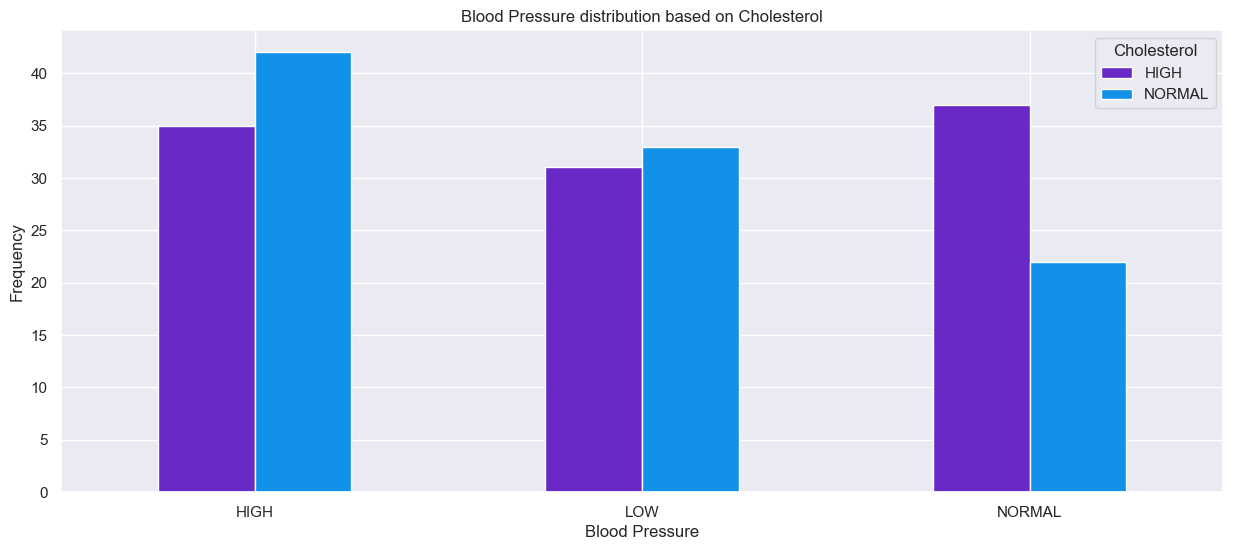

In [75]:
pd.crosstab(df_drug.BP,df_drug.Cholesterol).plot(kind="bar",figsize=(15,6),color=['#6929c4','#1192e8'])
plt.title('Blood Pressure distribution based on Cholesterol')
plt.xlabel('Blood Pressure')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

## Sodium to Potassian distribution based on Age & Gender

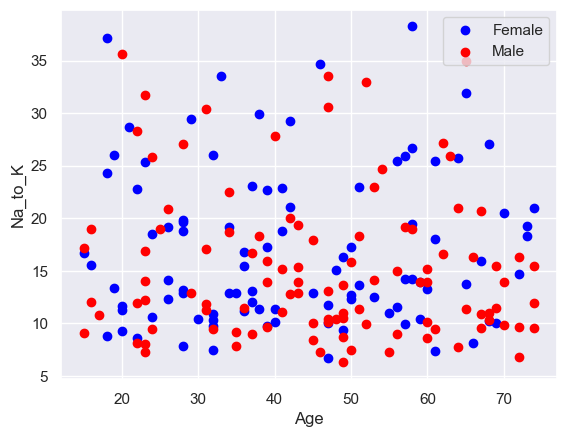

In [76]:
plt.scatter(x= df_drug.Age[df_drug.Sex == 'F'],y =df_drug.Na_to_K[df_drug.Sex =='F'],c ='Blue')
plt.scatter(x=df_drug.Age[df_drug.Sex=='M'],y = df_drug.Na_to_K[df_drug.Sex=='M'],c='Red')
plt.legend(['Female','Male'])
plt.xlabel('Age')
plt.ylabel('Na_to_K')
plt.show()

## Data Preparation

### Data Binnig

### Age

The age will be divided into 7 age categories:
- Below 20 y.o.
- 20 - 29 y.o.
- 30 - 39 y.o.
- 40 - 49 y.o.
- 50 - 59 y.o.
- 60 - 69 y.o.
- Above 70.

In [77]:
bin_age = [0,19,29,39,49,59,69,80]
category_age = ['<20','20s','30s','40s','50s','60s','>60s']
df_drug['Age_binned']  =pd.cut(df_drug['Age'],bins= bin_age,labels= category_age)
df_drug =df_drug.drop(['Age'],axis =1)

### Na_to_K

In [78]:
bin_NatoK  = [0,9,19,29,50]
category_NatoK = ['<10','10-20','20-30','>30']
df_drug['Na_to_K binned'] = pd.cut(df_drug['Na_to_K'],bins= bin_NatoK,labels= category_NatoK)
df_drug = df_drug.drop(['Na_to_K'],axis =1)

## Splitting the Dataset 

In [89]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [80]:
X = df_drug.drop(['Drug'],axis = 1)
Y = df_drug['Drug']

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=0)

## Feature Engineering

In [81]:
from sklearn.preprocessing import OneHotEncoder

In [82]:
encoder = OneHotEncoder()

In [83]:
X_train = pd.DataFrame(encoder.fit_transform(X_train).toarray())
X_test = pd.DataFrame(encoder.fit_transform(X_test).toarray())

## Synthetic Minority Over-sampling Technique - SMOTE

In [84]:
from imblearn.over_sampling import SMOTE

In [85]:
X_train,Y_train = SMOTE().fit_resample(X_train,Y_train)

C:\Users\nived\AppData\Local\Temp\ipykernel_11332\1081165580.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=Y_train, data=df_drug, palette="mako_r")


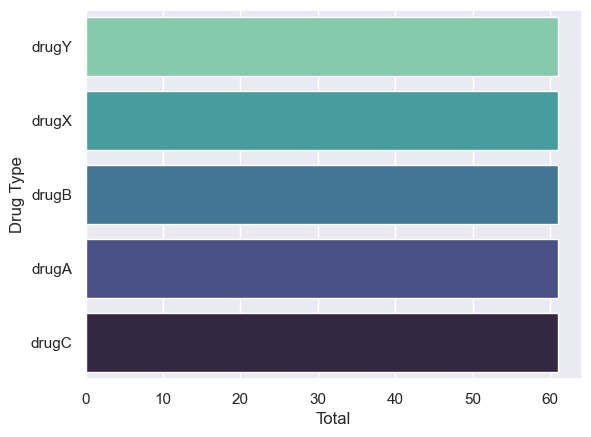

In [86]:
sns.set_theme(style="darkgrid")
sns.countplot(y=Y_train, data=df_drug, palette="mako_r")
plt.ylabel('Drug Type')
plt.xlabel('Total')
plt.show()

## Model

### Logistic Regression

In [87]:
from sklearn.linear_model import LogisticRegression

In [90]:
LRclassifier = LogisticRegression(solver='liblinear',max_iter=5000)
LRclassifier.fit(X_train,Y_train)

y_pred = LRclassifier.predict(X_test)

print(classification_report(Y_test,y_pred))
print(confusion_matrix(Y_test,y_pred))

from sklearn.metrics import accuracy_score
LRAcc = accuracy_score(Y_test,y_pred)

print('Logistic Regression Accuracy is: {:.2f}%'.format(LRAcc*100))

              precision    recall  f1-score   support

       drugA       0.71      1.00      0.83         5
       drugB       0.75      1.00      0.86         3
       drugC       0.67      1.00      0.80         4
       drugX       0.82      1.00      0.90        18
       drugY       1.00      0.70      0.82        30

    accuracy                           0.85        60
   macro avg       0.79      0.94      0.84        60
weighted avg       0.89      0.85      0.85        60

[[ 5  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 18  0]
 [ 2  1  2  4 21]]
Logistic Regression Accuracy is: 85.00%


## K-Neighbours

In [91]:
from sklearn.neighbors import KNeighborsClassifier

In [93]:
KNclassifier = KNeighborsClassifier(n_neighbors=20)
KNclassifier.fit(X_train,Y_train)

y_pred = KNclassifier.predict(X_test)

print(classification_report(Y_test,y_pred))
print(confusion_matrix(Y_test,y_pred))

from sklearn.metrics import accuracy_score

KNAcc = accuracy_score(y_pred,Y_test)
print('K Neighbors accuracy is: {:.2f}'.format(KNAcc*100))


              precision    recall  f1-score   support

       drugA       0.22      0.40      0.29         5
       drugB       0.38      1.00      0.55         3
       drugC       0.50      1.00      0.67         4
       drugX       0.77      0.94      0.85        18
       drugY       0.85      0.37      0.51        30

    accuracy                           0.62        60
   macro avg       0.54      0.74      0.57        60
weighted avg       0.73      0.62      0.61        60

[[ 2  1  0  0  2]
 [ 0  3  0  0  0]
 [ 0  0  4  0  0]
 [ 1  0  0 17  0]
 [ 6  4  4  5 11]]
K Neighbors accuracy is: 61.67


## Support Vendor Machine

In [94]:
from sklearn.svm import SVC

In [105]:
SVclassifier = SVC(kernel='linear',max_iter=251)
SVclassifier.fit(X_train,Y_train)

y_pred = SVclassifier.predict(X_test)

print(classification_report(Y_test,y_pred))
print(confusion_matrix(Y_test,y_pred))

from sklearn.metrics import accuracy_score
SVCAcc = accuracy_score(Y_test,y_pred)

print('Support Vendor Machine accuracy is: {:.2f}'.format(SVCAcc*100))

              precision    recall  f1-score   support

       drugA       0.71      1.00      0.83         5
       drugB       0.75      1.00      0.86         3
       drugC       0.67      1.00      0.80         4
       drugX       0.82      1.00      0.90        18
       drugY       1.00      0.70      0.82        30

    accuracy                           0.85        60
   macro avg       0.79      0.94      0.84        60
weighted avg       0.89      0.85      0.85        60

[[ 5  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 18  0]
 [ 2  1  2  4 21]]
Support Vendor Machine accuracy is: 85.00


D:\Anaconda\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=251).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


## Naive Bayes

### Categorical NB

In [97]:
from sklearn.naive_bayes import CategoricalNB

In [101]:
NBclassifier1 = CategoricalNB()
NBclassifier1.fit(X_train,Y_train)

y_pred = NBclassifier1.predict(X_test)

print(classification_report(y_pred,Y_test))
print(confusion_matrix(y_pred,Y_test))

from sklearn.metrics import accuracy_score
NBAcc1 = accuracy_score(Y_test,y_pred)

print('Naive Bayes Accuracy is: {:.2f}'.format(NBAcc*100))

              precision    recall  f1-score   support

       drugA       1.00      0.62      0.77         8
       drugB       1.00      0.75      0.86         4
       drugC       1.00      0.67      0.80         6
       drugX       1.00      0.82      0.90        22
       drugY       0.67      1.00      0.80        20

    accuracy                           0.83        60
   macro avg       0.93      0.77      0.83        60
weighted avg       0.89      0.83      0.84        60

[[ 5  0  0  0  3]
 [ 0  3  0  0  1]
 [ 0  0  4  0  2]
 [ 0  0  0 18  4]
 [ 0  0  0  0 20]]
Naive Bayes Accuracy is: 83.33


### Gaussian NB

In [100]:
from sklearn.naive_bayes import GaussianNB

In [103]:
NBclassifier2 = GaussianNB()
NBclassifier2.fit(X_train,Y_train)

y_pred = NBclassifier2.predict(X_test)

print(classification_report(Y_test,y_pred))
print(confusion_matrix(Y_test,y_pred))

from sklearn.metrics import accuracy_score
NBAcc2 = accuracy_score(Y_test,y_pred)

print('Gaussian NB accuracy is: {:.2f}'.format(NBAcc2*100) )

              precision    recall  f1-score   support

       drugA       0.71      1.00      0.83         5
       drugB       0.75      1.00      0.86         3
       drugC       0.67      1.00      0.80         4
       drugX       0.82      1.00      0.90        18
       drugY       1.00      0.70      0.82        30

    accuracy                           0.85        60
   macro avg       0.79      0.94      0.84        60
weighted avg       0.89      0.85      0.85        60

[[ 5  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 18  0]
 [ 2  1  2  4 21]]
Gaussian NB accuracy is: 85.00


# Model Comparison

In [106]:
compare = pd.DataFrame({'Model': ['Logistic Regression', 'K Neighbors', 'SVM', 'Categorical NB', 'Gaussian NB'],
                                  'Accuracy': [LRAcc*100, KNAcc*100, SVCAcc*100, NBAcc1*100, NBAcc2*100]})
compare.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
0,Logistic Regression,85.000000
2,SVM,85.000000
4,Gaussian NB,85.000000
3,Categorical NB,83.333333
1,K Neighbors,61.666667


In [107]:
import pickle

In [108]:
pickle.dump(LRclassifier,open('Finalmodel.pk1','wb'))

In [109]:
pickle.dump(encoder,open('Finalencoder.pk1','wb'))

In [110]:
model =pickle.load(open('Finalmodel.pk1','rb'))

In [115]:
enc = pickle.load(open('Finalencoder.pk1','rb'))

In [116]:
tt = np.array([['M','NORMAL','NORMAL','40s','>30']])

In [117]:
sc = enc.transform(tt)

D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [118]:
model.predict(sc)

array(['drugY'], dtype=object)

-----
      From the results, it can be seen that most of ML models can reach up to 80% accuracy in predicting classification of drug type.
-----